## Tarea 3 y 4 de simulación:  Movimiento Browniano y Cálculo de Itô
### Rojas Irineo Alejandro

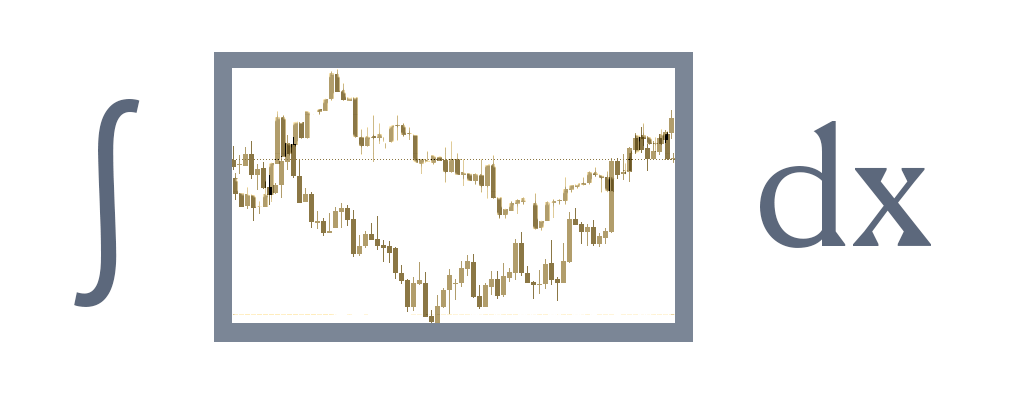

# *- Movimiento Browniano*

Consideremos una sucesión de variables aleatorias independientes e idénticamente distribuidas:$$\xi_1, \xi_2, \dots$$tales que:$$\mathbb{P}(\xi_i = 1) = \mathbb{P}(\xi_i = -1) = \frac{1}{2}$$Definimos la caminata aleatoria simple por:$$S_k = \sum_{i=1}^{k} \xi_i, \quad S_0 = 0$$Para cada $n \in \mathbb{N}$, definimos el proceso reescalado e interpolado linealmente por:$$B^{(n)}_t = \frac{1}{\sqrt{n}} S_{\lfloor nt \rfloor} + \frac{nt - \lfloor nt \rfloor}{\sqrt{n}} \xi_{\lfloor nt \rfloor + 1}, \quad t \ge 0$$Este proceso puede interpretarse como una caminata aleatoria reescalada en espacio y en tiempo. Cuando $n$ es grande, el proceso $B^{(n)}_t$ se aproxima en distribución a un movimiento Browniano estándar $(B_t)_{t \ge 0}$.

En el siguiente código realizamos dicho proceso:

In [33]:
# Cargamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Ponemos una semilla para reproducibilidad
np.random.seed(0)


1. Simulamos una caminata aleatoria simple $(S_k)_{k=0}^n$ para varios valores de $n$, por ejemplo $n \in \{100, 500, 1000, 5000\}$.

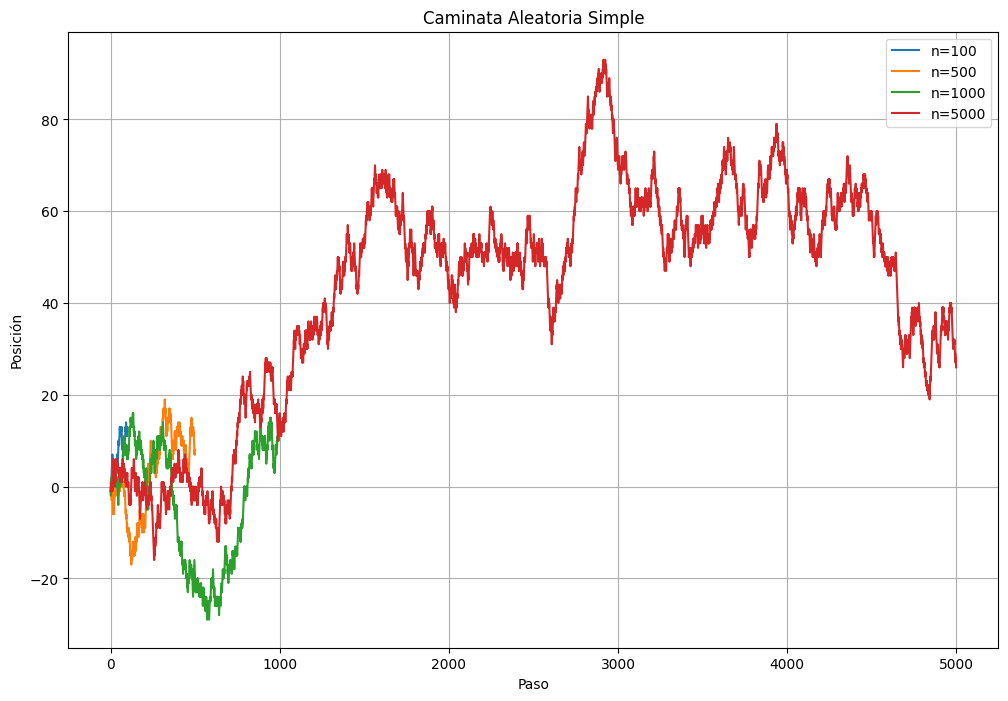

In [2]:
# Simulemos una caminata aleatoria simple para varios valores de n
def caminata_aleatoria(n):
    # Generamos pasos aleatorios: +1 o -1
    pasos = np.random.choice([-1, 1], size = n)
    # Calculamos la posición acumulada
    posicion = np.cumsum(pasos)
    return posicion

# Definimos los valores de n para los que queremos simular la caminata
n_valores = [100, 500, 1000, 5000]

# Simulamos y graficamos la caminata para cada valor de n
plt.figure(figsize=(12, 8)) 
for n in n_valores:
    caminata = caminata_aleatoria(n)
    plt.plot(caminata, label = f"n={n}")

plt.title("Caminata Aleatoria Simple")
plt.xlabel("Paso")
plt.ylabel("Posición")
plt.legend()
plt.grid()
plt.show()


2. Para cada valor de $n$, construimos el proceso reescalado e interpolado, definido al inicio

In [3]:
# Construyamos el proceso reescalado e interpolado
def B_t(n):
    caminata = caminata_aleatoria(n)
    # Reescalamos la caminata dividiendo por raiz de n
    reescalada = caminata / np.sqrt(n)
    return reescalada



3. Graficamos varias trayectorias de $B^{(n)}_t$ para distintos valores de $n$

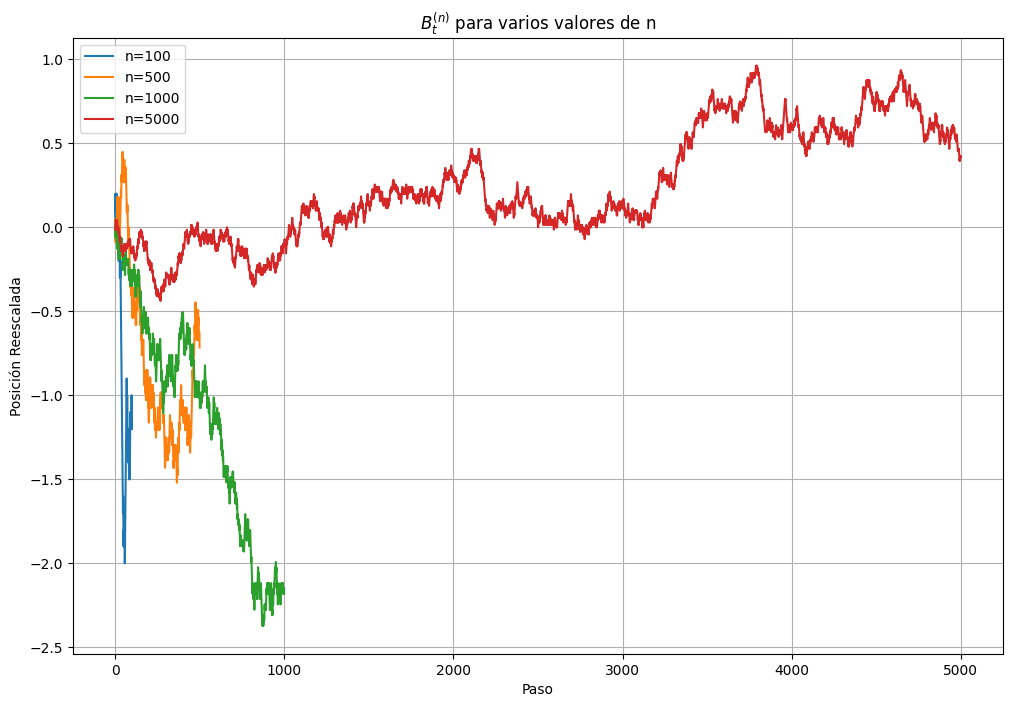

In [6]:
# Ahora grafiquemos B_t para varios valores de n en el mismo gráfico para comparar
plt.figure(figsize=(12, 8))
for n in n_valores:
    reescalada = B_t(n)
    plt.plot(reescalada, label = f"n={n}")
plt.title("$B^{(n)}_t$ para varios valores de n")
plt.xlabel("Paso")
plt.ylabel("Posición Reescalada")
plt.legend()
plt.grid()
plt.show()


Al observar las trayectorias, lo primero que destaca es cómo cambia la textura de las líneas. Cuando $n$ es pequeño (como en $n=100$), la gráfica se ve casi como segmentos rectos unidos donde es relativamente fácil notar cada paso. Sin embargo, conforme aumentamos el valor de $n$ hasta $5000$, la línea se vuelve muchísimo más irregular, pues ya no se alcanzan a distinguir los pasos individuales, y en su lugar vemos un trazo continuo que cambia de dirección a cada instante. También es importante notar que, aunque la línea con más pasos hace muchos más movimientos, la altura de la gráfica no se dispara al infinito, sino que se mantiene en un rango de valores similar a las demás. Esto se debe a que estamos dividiendo todo entre la raíz de $n$, lo que sirve para controlar el tamaño y nos permite ver visualmente cómo, al hacer los pasos más pequeños y rápidos, la caminata aleatoria toma la forma de un movimiento Browniano

4. Para $n = 5000$, simulamos $M = 1000$ trayectorias independientes de $B^{(n)}_t$. Para cada trayectoria, registramos el valor $B^{(n)}_1$.

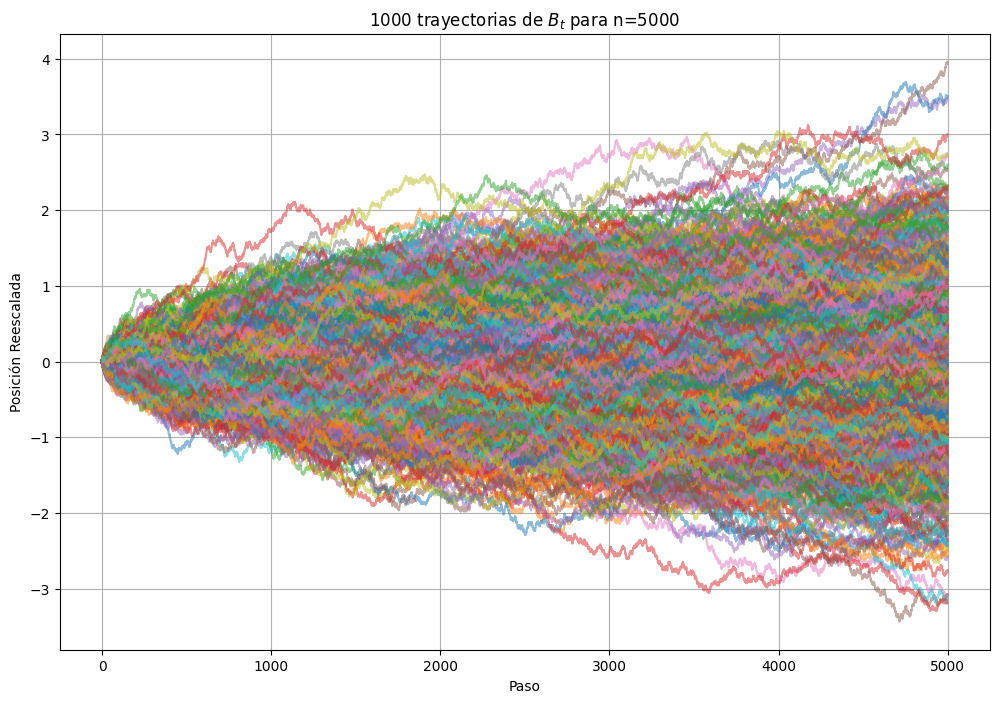

In [7]:
# Ahora simulemos para n = 5000 simulemos M = 1000 trayectorias de B_t y grafiquemos
ene = 5000
M = 1000
B_1_valores = []
plt.figure(figsize=(12, 8))
for i in range(M):
    reescalada = B_t(ene)
    B_1_valores.append(reescalada[-1])  # Guardamos el valor de B_1
    if i < 1000:  # Graficamos las trayectorias
        plt.plot(reescalada, alpha=0.5)
plt.title(f"1000 trayectorias de $B_t$ para n={n}")
plt.xlabel("Paso")
plt.ylabel("Posición Reescalada")
plt.grid()
plt.show()


5. Construimos ahora un histograma de los valores $B^{(n)}_1$ y lo comparamos con la densidad de una normal estándar $\mathcal{N}(0, 1)$.

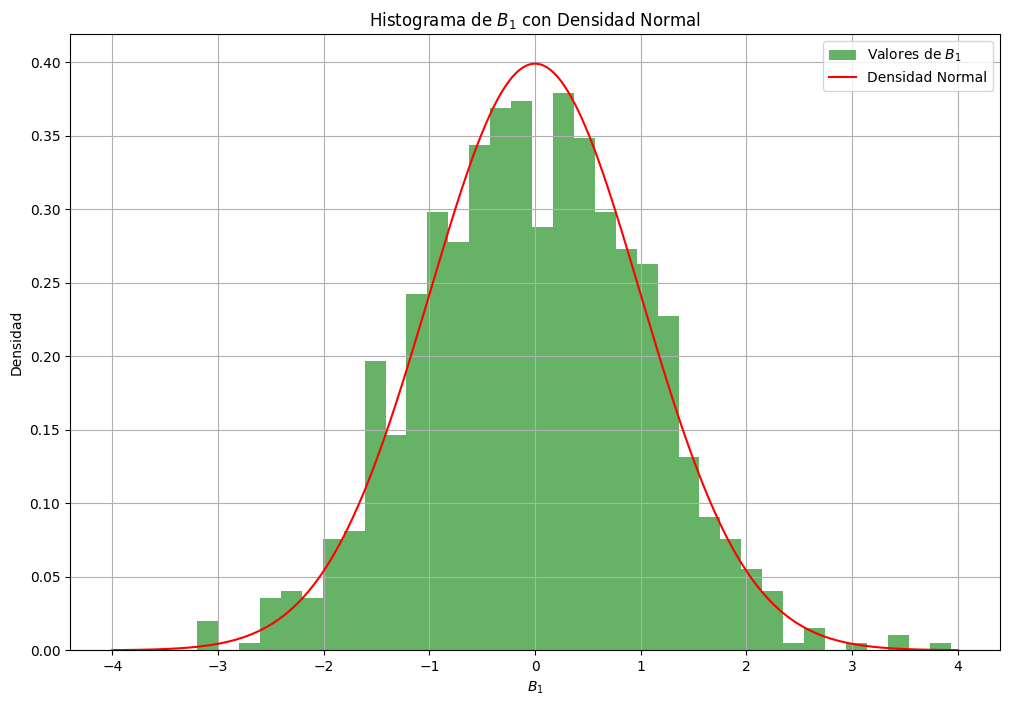

In [25]:
# Realizamos un histograma de los valores de B_1 y superponemos la densidad de la distribución normal estándar
plt.figure(figsize = (12, 8)) 
plt.hist(B_1_valores, bins = 36, density = True, alpha = 0.6, color = "g", label = "Valores de $B_1$")
# Superponemos la densidad de la distribución normal 
x = np.linspace(-4, 4, 1000)
pdf = (1/np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
plt.plot(x, pdf, "r-", label = "Densidad Normal")
plt.title("Histograma de $B_1$ con Densidad Normal")
plt.xlabel("$B_1$")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()

Como podemos observar en la gráfica, el histograma verde que agrupa los puntos finales de nuestras 1000 trayectorias se ajusta casi a la perfección a la campana roja, que representa la distribución normal estándar. Esto comprueba de forma práctica lo que nos dice la teoría: si hacemos que el número de pasos ($n$) sea lo suficientemente grande, nuestra caminata aleatoria reescalada termina comportándose como un Movimiento Browniano real. Dado que la teoría dicta que un Movimiento Browniano en el tiempo $t=1$ debe tener una distribución $\mathcal{N}(0, 1)$, el hecho de que nuestros datos simulados formen esa misma curva nos confirma visualmente el Teorema del Límite Central y demuestra que nuestra simulación es correcta.

#### Aplicaciones de SDE: Métodos MCMC basados en dinámica de Langevin

Consideremos una distribución de probabilidad $p^\star$ definida en $\mathbb{R}^d$. Una estrategia natural para obtener muestras aproximadas de $p^\star$ consiste en construir un proceso estocástico cuya distribución estacionaria sea precisamente $p^\star$. En particular, podemos considerar la siguiente ecuación diferencial estocástica:$$dX_t = \nabla \log p^\star(X_t) dt + \sqrt{2} dB_t, \tag{1}$$donde $(B_t)_{t \ge 0}$ es un movimiento Browniano estándar en $\mathbb{R}^d$. Bajo condiciones apropiadas sobre $p^\star$, la distribución de $X_t$ converge a $p^\star$ cuando $t \to \infty$. Por lo tanto, una forma de aproximar muestras de $p^\star$ es discretizar numéricamente la SDE (1). Sin embargo, una salvedad importante es que la discretización puede introducir sesgo. La discretización de Euler–Maruyama de la SDE (1) está dada por:$$X_n = X_{n-1} + \gamma \nabla \log p^\star(X_{n-1}) + \sqrt{2\gamma} Z_n, \tag{2}$$donde $\gamma > 0$ es el tamaño de paso y $Z_n \sim \mathcal{N}(0, I_d)$.

# *- Algoritmo MALA* 


Una forma de corregir el sesgo inducido por la discretización consiste en agregar un paso de aceptación o rechazo de tipo Metropolis–Hastings. Dado el estado actual $X_{n-1} = x$, se propone:$$Y_n = x + \gamma \nabla \log p^\star(x) + \sqrt{2\gamma} Z_n, \quad Z_n \sim \mathcal{N}(0, I_d). \tag{3}$$La densidad de transición de esta propuesta es:$$q_\gamma(y \mid x) = \mathcal{N}(y; x + \gamma \nabla \log p^\star(x), 2\gamma I_d).$$La propuesta $Y_n = y$ se acepta con probabilidad:$$\alpha(x, y) = \min\left(1, \frac{p^\star(y)q_\gamma(x \mid y)}{p^\star(x)q_\gamma(y \mid x)}\right). \tag{4}$$De manera explícita:$$\alpha(x, y) = \min\left(1, \frac{p^\star(y)\mathcal{N}(x; y + \gamma \nabla \log p^\star(y), 2\gamma I_d)}{p^\star(x)\mathcal{N}(y; x + \gamma \nabla \log p^\star(x), 2\gamma I_d)}\right).$$Si la propuesta es aceptada, se define $X_n = Y_n$. En caso contrario, se define $X_n = X_{n-1}$. Este procedimiento da lugar al algoritmo conocido como Metropolis-Adjusted Langevin Algorithm (MALA).

Para nuestro caso consideremos una distribución normal univariada:$$p_*(x) = \mathcal{N}(\mu, \sigma^2)$$Ahora calculemos $\nabla \log p_*(x)$:$$\nabla \left( \log\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{(x-\mu)^2}{2\sigma^2} \right) = - \frac{2(x-\mu)}{2\sigma^2} = - \frac{x-\mu}{\sigma^2} \tag{5}$$

Ahora escribiendo el algoritmo MALA: 

Propuesta:$$Y_n = x - \gamma \left( \frac{x-\mu}{\sigma^2} \right) + \sqrt{2\gamma} Z_n, \quad \text{con } Z_n  \sim \mathcal{N}(0, 1) \text{ y } x = X_{n-1}$$Densidad de transición:$$q_\gamma(y \mid x) = \mathcal{N}\left(y; x - \gamma \left( \frac{x-\mu}{\sigma^2} \right), 2\gamma\right), \quad \text{con } x = X_{n-1}$$Probabilidad de aceptación:$$\alpha(x, y) = \min\left(1, \frac{p_*(y)q_\gamma(x \mid y)}{p_*(x)q_\gamma(y \mid x)}\right)$$

Programamos el algoritmo:

In [19]:
# Construyamos el algoritmo MALA
def MALA(pasos, gamma, mu, sigma2, x_0):
    x = np.zeros(pasos)
    x[0] = x_0

    for i in range(1, pasos):
        Z = np.random.randn()
        grad_log_p = -(x[i-1] - mu) / sigma2
        y_propuesta = x[i-1] + gamma * grad_log_p + np.sqrt(2 * gamma) * Z
        
        # Calculamos la probabilidad de aceptación alpha
        p_y = norm.pdf(y_propuesta, mu, np.sqrt(sigma2))
        p_x = norm.pdf(x[i-1], mu, np.sqrt(sigma2))
        
        q_x_dado_y = norm.pdf(x[i-1], y_propuesta + gamma * (-(y_propuesta - mu) / sigma2), np.sqrt(2 * gamma))
        q_y_dado_x = norm.pdf(y_propuesta, x[i-1] + gamma * (-(x[i-1] - mu) / sigma2), np.sqrt(2 * gamma))
        
        cociente = (p_y * q_x_dado_y) / (p_x * q_y_dado_x)
        alpha = min(1.0, cociente)
        
        U = np.random.uniform(0, 1)
        if U < alpha:
            x[i] = y_propuesta
        else:
            x[i] = x[i-1]
    return x


Con la función que creamos simulamos una cadena escogiendo valores concretos de $\mu$ y $\sigma$

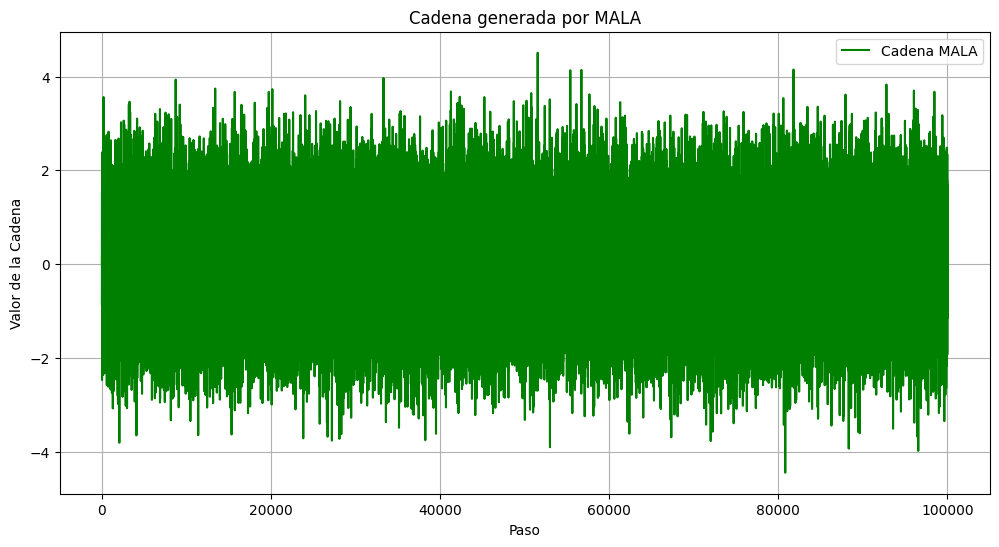

In [43]:
# Usemos la función MALA para generar una cadena y graficarla
pasos = 100000
gamma = 0.5
mu = 0.0
sigma2 = 1.0
cadena_mala = MALA(pasos, gamma, mu, sigma2, x_0 = 0)
# Graficamos la cadena generada por MALA
plt.figure(figsize=(12, 6))
plt.plot(cadena_mala, label = "Cadena MALA", color = "green")
plt.title(f"Cadena generada por MALA")
plt.xlabel("Paso")
plt.ylabel("Valor de la Cadena")
plt.legend()
plt.grid()
plt.show()

Generamos el histograma de las cadena obtenida y lo comparamos con la densidad verdadera de la distribución $N$($\mu$, $\sigma^2$)

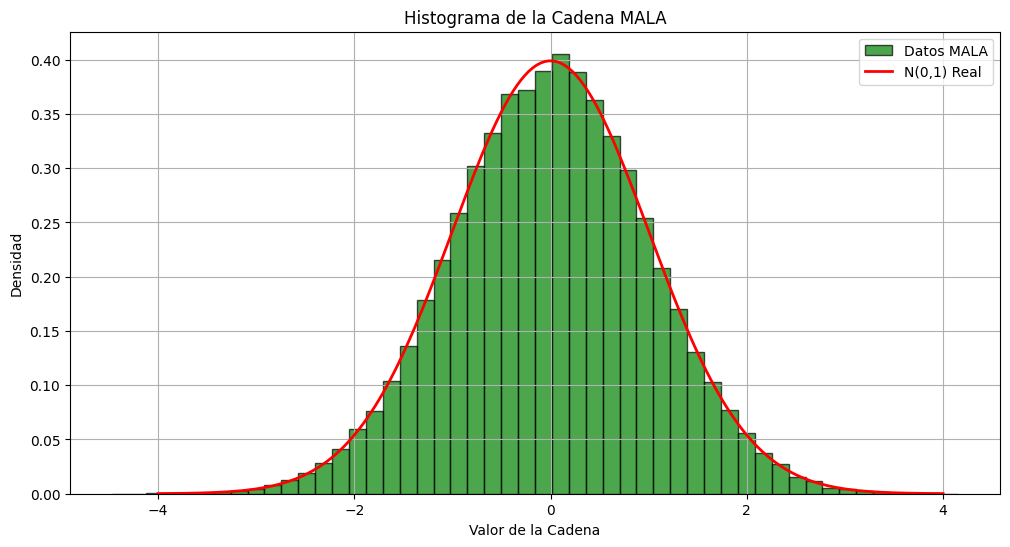

In [39]:
# Obtengamos ahora el histograma de la cadena MALA y superpongamos la densidad de una normal
plt.figure(figsize = (12, 6))
plt.hist(cadena_mala, bins = 50, density = True, alpha = 0.7, color = "green", edgecolor = "black", label = "Datos MALA")
x_rango = np.linspace(-4, 4, 200)
plt.plot(x_rango, norm.pdf(x_rango, mu, np.sqrt(sigma2)), "r", lw = 2, label = "N(0,1) Real")
plt.title(f"Histograma de la Cadena MALA")
plt.xlabel("Valor de la Cadena")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()


En esta gráfica podemos ver el resultado final de nuestra simulación utilizando el algoritmo MALA. El histograma verde agrupa todos los valores que fue generando nuestra cadena paso a paso, y se nota claramente cómo se ajustan a la perfección a la curva roja, que es la distribución normal estándar $\mathcal{N}(0, 1)$. Esto nos confirma visualmente que nuestro algoritmo fue un éxito: logramos construir un proceso que fabrica datos nuevos y estos logran reconstruir exactamente la distribución que queríamos.

# - *Agoritmo ULA*

En dimensiones altas, el paso de aceptación o rechazo puede ser costoso o incluso producir tasas de aceptación muy bajas, lo cual deteriora la eficiencia del algoritmo. Una alternativa consiste en omitir el paso de Metropolis–Hastings y utilizar directamente la discretización (2). Este método se conoce como Unadjusted Langevin Algorithm (ULA).El algoritmo ULA está dado por la recursión:$$X_n = X_{n-1} + \gamma \nabla \log p^\star(X_{n-1}) + \sqrt{2\gamma} Z_n, \quad Z_n \sim \mathcal{N}(0, I_d). \tag{6}$$A diferencia de MALA, el algoritmo ULA no corrige el sesgo producido por la discretización. En general, su distribución estacionaria no es exactamente $p^\star$, sino una distribución $p^\gamma_\star$ que depende del tamaño de paso $\gamma$. Sin embargo, bajo condiciones apropiadas, puede demostrarse que $p^\gamma_\star$ se aproxima a $p^\star$ cuando $\gamma \to 0$. Por esta razón, ULA puede ser una alternativa viable cuando el paso de Metropolis–Hastings es demasiado costoso.

Escribiendo la recursión del algoritmo ULA para este caso particular usando lo obtenido en $(5)$:$$X_n = X_{n-1} + \gamma \left( - \frac{X_{n-1}-\mu}{\sigma^2} \right) + \sqrt{2\gamma} Z_n, \quad \text{donde } Z_n \sim \mathcal{N}(0, 1)$$

Programamos el algoritmo:

In [45]:
# Construyamos primero el algoritmo ULA 

def ULA(pasos, gamma, mu, sigma2, x_0):
    x = np.zeros(pasos)
    x[0] = x_0

    for i in range(1, pasos):
        Z = np.random.randn()
        grad_log_p = -(x[i-1] - mu) / sigma2
        x[i] = x[i-1] + gamma * grad_log_p + np.sqrt(2 * gamma) * Z
    return x




Con la función que creamos simulamos una cadena escogiendo valores concretos de $\mu$ y $\sigma$

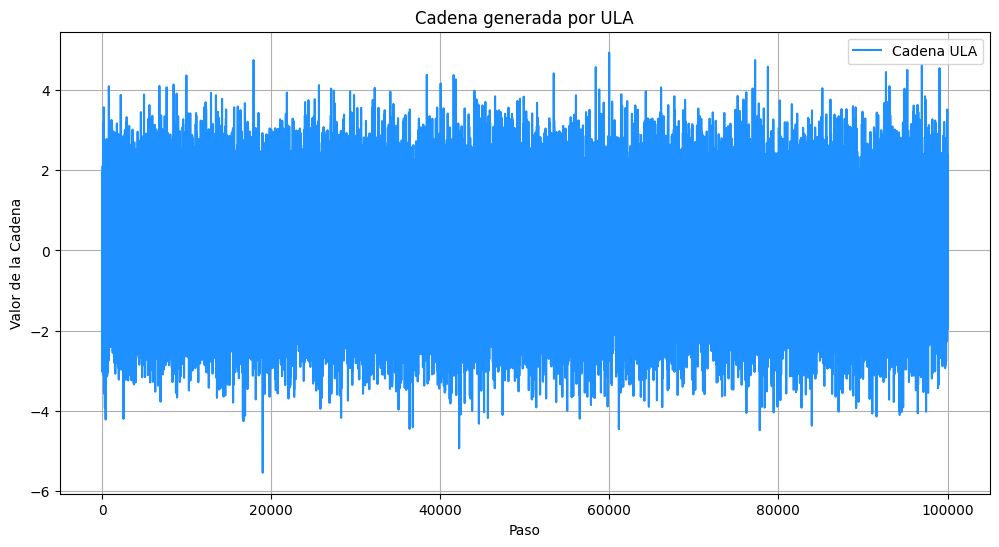

In [47]:
# Usemos la función ULA para generar una cadena y graficarla
pasos = 100000
gamma = 0.5
mu = 0.0
sigma2 = 1.0
cadena_ula = ULA(pasos, gamma, mu, sigma2, x_0 = 0)
plt.figure(figsize=(12, 6))
plt.plot(cadena_ula, label = "Cadena ULA", alpha = 1.0, color = "DodgerBlue")
plt.title(f"Cadena generada por ULA")
plt.xlabel("Paso")
plt.ylabel("Valor de la Cadena")
plt.legend()
plt.grid()
plt.show()

Generamos el histograma de las cadena obtenida y lo comparamos con la densidad verdadera de la distribución $N$($\mu$, $\sigma^2$)

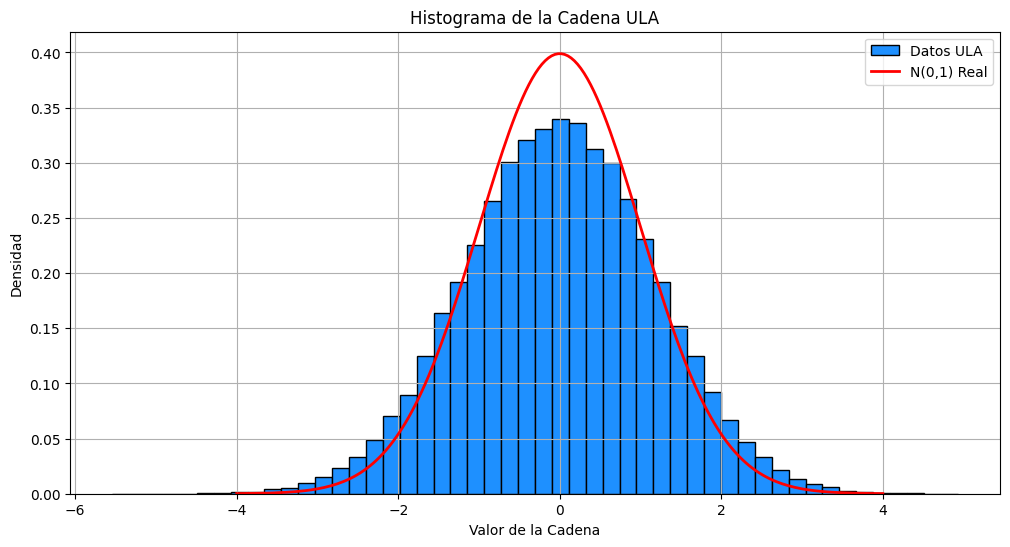

In [49]:
# Obtengamos ahora el histograma de los valores de la cadena ULA y superpongamos la densidad de una normal
plt.figure(figsize = (12, 6))
plt.hist(cadena_ula, bins = 50, density = True, alpha = 1.0, color = "DodgerBlue", edgecolor = "black", label = "Datos ULA")
x_rango = np.linspace(-4, 4, 200)   
plt.plot(x_rango, norm.pdf(x_rango, mu, np.sqrt(sigma2)), "r", lw = 2, label = "N(0,1) Real")
plt.title(f"Histograma de la Cadena ULA")
plt.xlabel("Valor de la Cadena")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()


En esta gráfica vemos el resultado de utilizar el algoritmo ULA. Si recordamos la gráfica anterior de MALA, aquí se nota a simple vista una gran diferencia: el histograma ya no encaja perfectamente con la curva roja; de hecho, se ve un poco más "aplastado" y ancho, y no alcanza la misma altura en el centro. Esto ilustra exactamente lo que nos dice la teoría: como ULA se salta el paso de "aceptar o rechazar", no corrige el sesgo que se va acumulando en cada paso. Por lo tanto, aunque los datos simulados tienen forma de campana y se parecen a lo que buscamos, no logran replicar la distribución normal estándar con la misma exactitud que MALA

Finalmente probemos nuestro algoritmo con diferentes valores de $\gamma$ (omitimos $0.5$, pues se probo en el ejemplo anterior): $$\gamma \in \{1, 0.1, 0.05, 0.01\}$$

- $\gamma = 1$

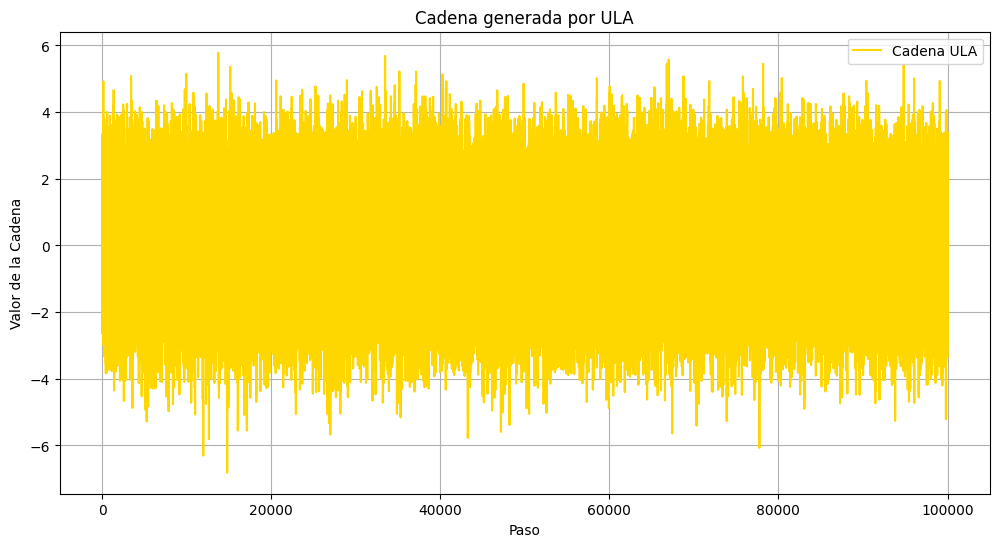

In [50]:
# Obtengamos ahora la cadena ULA con gamma = 1 y grafiquémosla
cadena_ula2 = ULA(pasos, 1, mu, sigma2, x_0 = 0)
plt.figure(figsize=(12, 6))
plt.plot(cadena_ula2, label = "Cadena ULA", alpha = 1.0, color = "gold")
plt.title(f"Cadena generada por ULA")
plt.xlabel("Paso")
plt.ylabel("Valor de la Cadena")
plt.legend()
plt.grid()
plt.show()

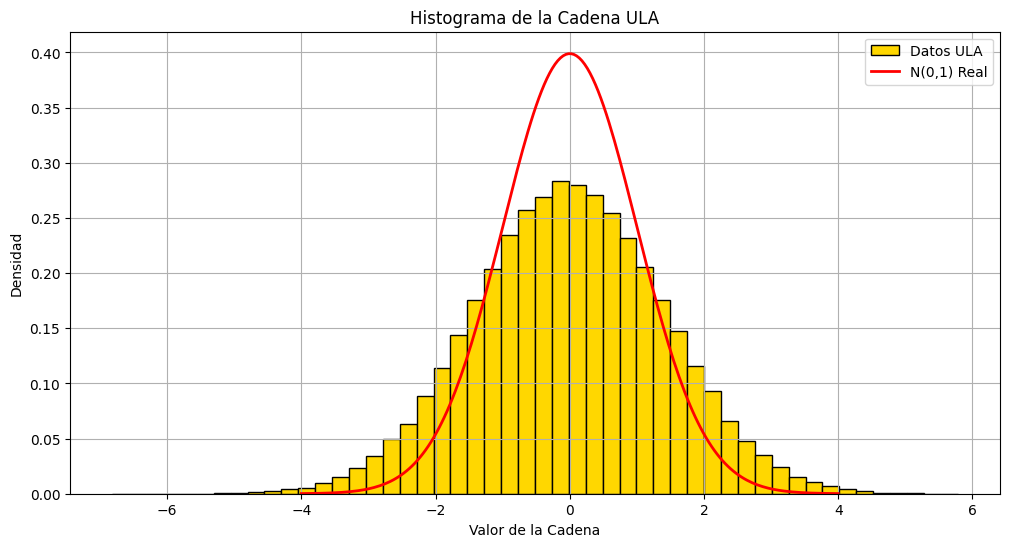

In [51]:
# Obtengamos ahora el histograma de la cadena ULA con gamma = 1 y superpongamos la densidad de una normal
plt.figure(figsize = (12, 6))
plt.hist(cadena_ula2, bins = 50, density = True, alpha = 1.0, color = "gold", edgecolor = "black", label = "Datos ULA")
x_rango = np.linspace(-4, 4, 200)   
plt.plot(x_rango, norm.pdf(x_rango, mu, np.sqrt(sigma2)), "r", lw = 2, label = "N(0,1) Real")
plt.title(f"Histograma de la Cadena ULA")
plt.xlabel("Valor de la Cadena")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()

- $\gamma = 0.1$

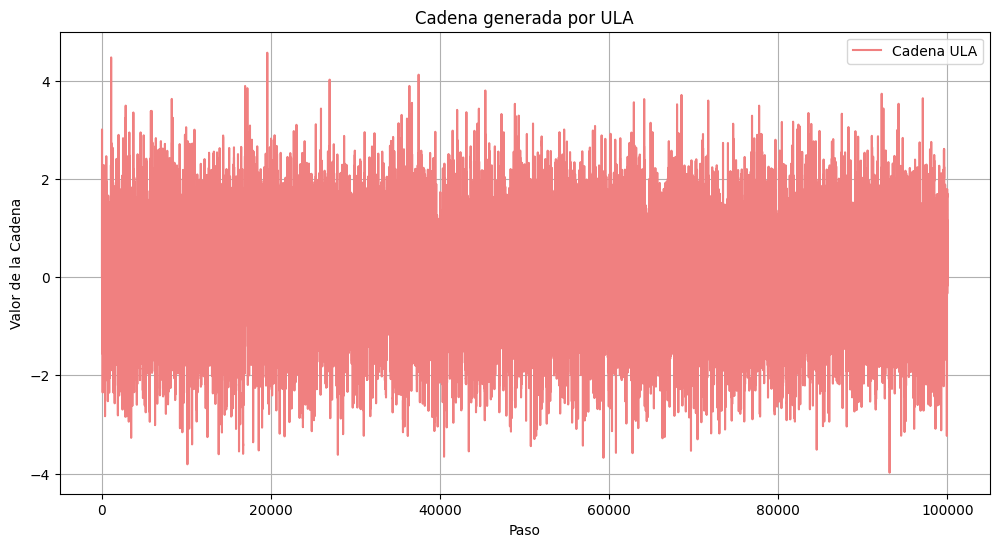

In [55]:
# Obtengamos ahora la cadena ULA con gamma = 0.1 y grafiquémosla
cadena_ula3 = ULA(pasos, 0.1, mu, sigma2, x_0 = 0)
plt.figure(figsize=(12, 6))
plt.plot(cadena_ula3, label = "Cadena ULA", alpha = 1.0, color = "lightcoral")
plt.title(f"Cadena generada por ULA")
plt.xlabel("Paso")
plt.ylabel("Valor de la Cadena")
plt.legend()
plt.grid()
plt.show()

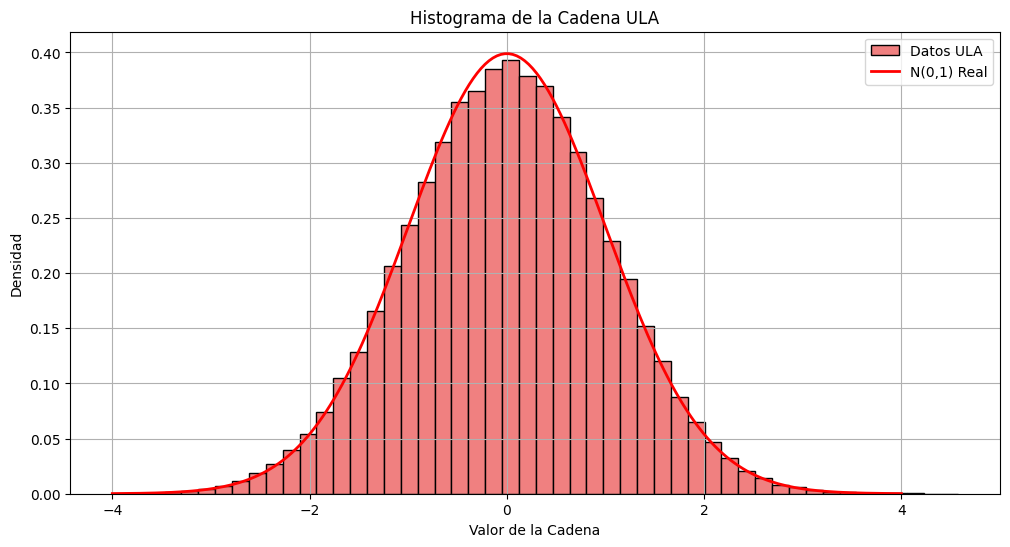

In [56]:
# Obtengamos ahora el histograma de la cadena ULA con gamma = 0.1 y superpongamos la densidad de una normal
plt.figure(figsize = (12, 6))
plt.hist(cadena_ula3, bins = 50, density = True, alpha = 1.0, color = "lightcoral", edgecolor = "black", label = "Datos ULA")
x_rango = np.linspace(-4, 4, 200)   
plt.plot(x_rango, norm.pdf(x_rango, mu, np.sqrt(sigma2)), "r", lw = 2, label = "N(0,1) Real")
plt.title(f"Histograma de la Cadena ULA")
plt.xlabel("Valor de la Cadena")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()

- $\gamma = 0.05$

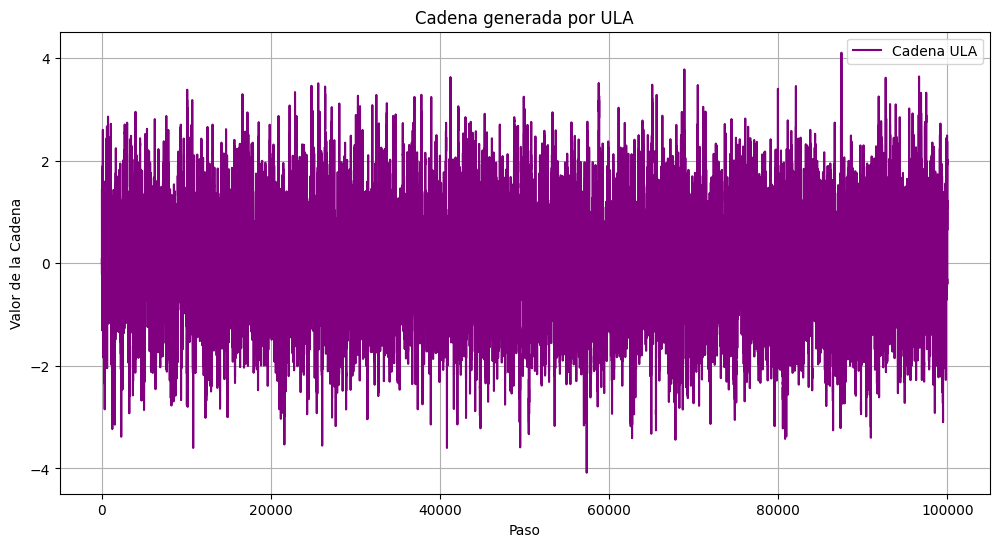

In [58]:
# Obtengamos ahora la cadena ULA con gamma = 0.05 y grafiquémosla
cadena_ula4 = ULA(pasos, 0.05, mu, sigma2, x_0 = 0)
plt.figure(figsize=(12, 6))
plt.plot(cadena_ula4, label = "Cadena ULA", alpha = 1.0, color = "purple")
plt.title(f"Cadena generada por ULA")
plt.xlabel("Paso")
plt.ylabel("Valor de la Cadena")
plt.legend()
plt.grid()
plt.show()

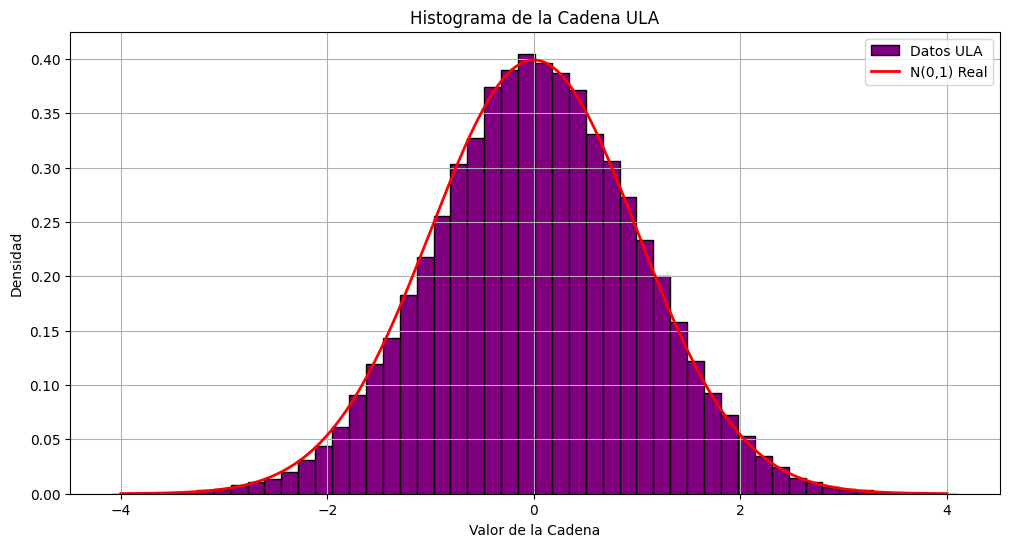

In [59]:
# Obtengamos ahora el histograma de la cadena ULA con gamma = 0.05 y superpongamos la densidad de una normal
plt.figure(figsize = (12, 6))
plt.hist(cadena_ula4, bins = 50, density = True, alpha = 1.0, color = "purple", edgecolor = "black", label = "Datos ULA")
x_rango = np.linspace(-4, 4, 200)   
plt.plot(x_rango, norm.pdf(x_rango, mu, np.sqrt(sigma2)), "r", lw = 2, label = "N(0,1) Real")
plt.title(f"Histograma de la Cadena ULA")
plt.xlabel("Valor de la Cadena")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()

- $\gamma = 0.01$

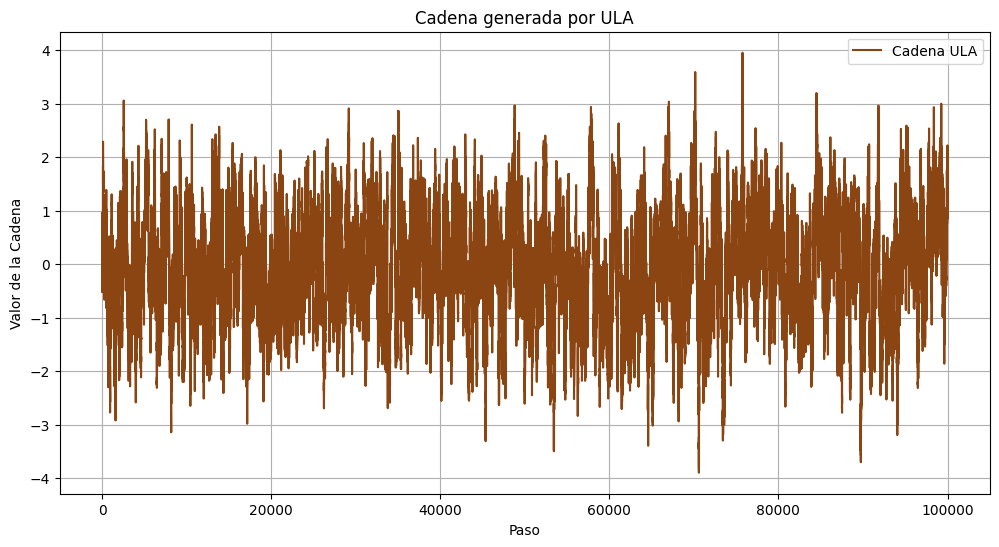

In [66]:
# Obtengamos ahora la cadena ULA con gamma = 0.01 y graficémosla 
cadena_ula5 = ULA(pasos, 0.01, mu, sigma2, x_0 = 0)
plt.figure(figsize=(12, 6))
plt.plot(cadena_ula5, label = "Cadena ULA", alpha = 1.0, color = "saddlebrown")
plt.title(f"Cadena generada por ULA")
plt.xlabel("Paso")
plt.ylabel("Valor de la Cadena")
plt.legend()
plt.grid()
plt.show()

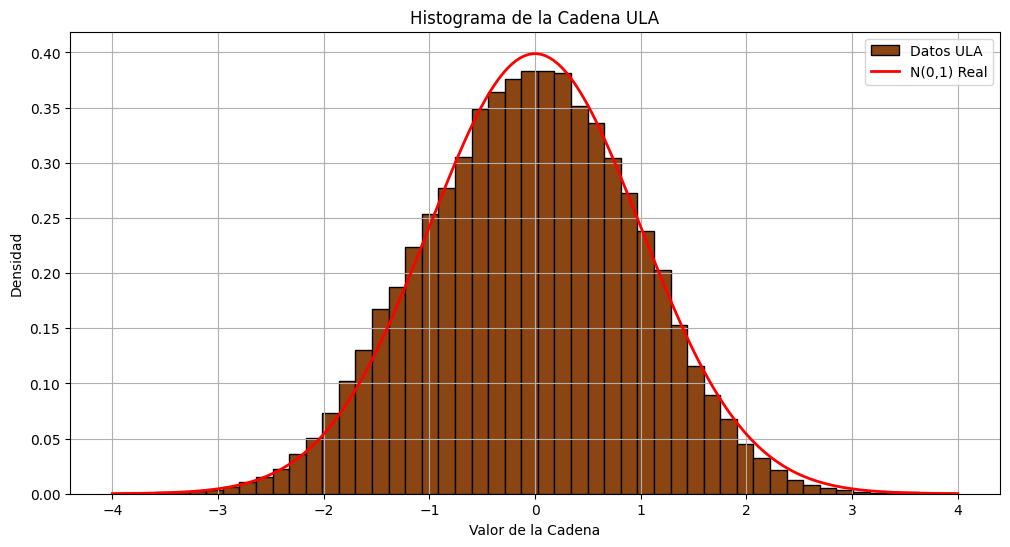

In [67]:
# Obtengamos ahora el histograma de la cadena ULA con gamma = 0.01 y superpongamos la densidad de una normal
plt.figure(figsize = (12, 6))
plt.hist(cadena_ula5, bins = 50, density = True, alpha = 1.0, color = "saddlebrown", edgecolor = "black", label = "Datos ULA")
x_rango = np.linspace(-4, 4, 200)   
plt.plot(x_rango, norm.pdf(x_rango, mu, np.sqrt(sigma2)), "r", lw = 2, label = "N(0,1) Real")
plt.title(f"Histograma de la Cadena ULA")
plt.xlabel("Valor de la Cadena")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()

Como podemos observar al ir disminuyendo el valor de $\gamma$ (pasando de 1 hasta 0.01), la forma del histograma generado por el algoritmo ULA mejora significativamente y se va pareciendo cada vez más a la curva roja de la distribución normal estándar. Esto ocurre porque, al hacer que el tamaño de paso sea más pequeño, el sesgo que se acumula por saltarnos el paso de "aceptar o rechazar" (que sí tiene MALA) se vuelve muchísimo menor. Con esto comprobamos visualmente lo que nos dicta la teoría: la distribución que genera ULA se aproxima a la distribución que queremos cuando $\gamma$ tiende a 0. En conclusión, si queremos usar ULA porque es más rápido y barato computacionalmente, el "precio a pagar" es que debemos usar un valor de $\gamma$ muy pequeño para asegurar que nuestra simulación sea precisa.